In [1]:
import seaborn as sns
import numpy as np

# query

Provide the python code for drawing a hierarchically clustered heatmap with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.

# new

In [2]:
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# We'll visualize the top 10 most variable genes for simplicity
# First, compute the variable genes if they are not already present
sc.pp.highly_variable_genes(adata, n_top_genes=10)

# Extract the highly variable genes' data
adata_var = adata[:, adata.var['highly_variable']]

# Perform clustering - this is required for hierarchical clustering heatmaps
sc.tl.dendrogram(adata_var, n_pcs=20)

# Plot the heatmap
sc.pl.heatmap(adata_var, var_names=adata_var.var_names,
             groupby='louvain', dendrogram=True)

TypeError: dendrogram() missing 1 required positional argument: 'groupby'

### 1. without checking adata.obs, dendrogram not know 'louvain' exists, which can be used to groupby

### 2. this example is not good, because it doesn't say the objective is to use 'louvain' as the hierachy. If given the original count matrix, no information of 'groupby' is given.

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


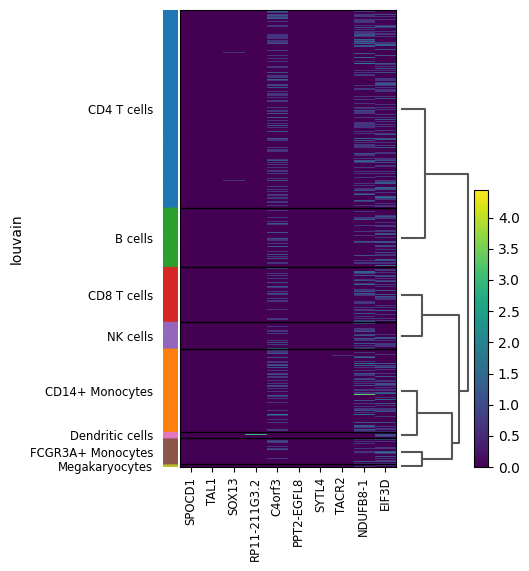

In [4]:
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# We'll visualize the top 10 most variable genes for simplicity
# First, compute the variable genes if they are not already present
sc.pp.highly_variable_genes(adata, n_top_genes=10)

# Extract the highly variable genes' data
adata_var = adata[:, adata.var['highly_variable']]

# Perform clustering - this is required for hierarchical clustering heatmaps
sc.tl.dendrogram(adata_var, n_pcs=20, groupby='louvain')

# Plot the heatmap
sc.pl.heatmap(adata_var, var_names=adata_var.var_names,
             groupby='louvain', dendrogram=True)